# Day 2 — Gradient Descent from Scratch

yesterday we found the best w by testing every value manually  
today we build the algorithm that finds it automatically  

the idea: start with a random w and b, then keep adjusting them step by step until MSE is as low as possible

In [7]:
import matplotlib.pyplot as plt

In [1]:
x_train = [1, 2, 3, 4, 5]
y_train = [2, 4, 6, 8, 10]  # y = 2x so perfect w=2, b=0

# starting point — gradient descent will fix these automatically
w = 0.0
b = 0.0

alpha = 0.01   # learning rate — how big each step is
epochs = 100   # how many times we update w and b

In [2]:
def compute_cost(x, y, w, b):
    m = len(x)
    total = 0
    for i in range(m):
        pred = w * x[i] + b
        total += (pred - y[i]) ** 2
    return (1 / (2 * m)) * total

In [3]:
def compute_gradients(x, y, w, b):
    m = len(x)
    dw = 0  # derivative with respect to w
    db = 0  # derivative with respect to b

    for i in range(m):
        pred = w * x[i] + b
        error = pred - y[i]
        dw += error * x[i]  # how much w contributed to the error
        db += error         # how much b contributed to the error

    dw = dw / m
    db = db / m
    return dw, db

In [6]:
def gradient_descent(x, y, w, b, alpha, epochs):
    cost_history = []  # track cost each epoch to plot later

    for epoch in range(epochs):
        dw, db = compute_gradients(x, y, w, b)

        w = w - alpha * dw  # move w in the opposite direction of the slope
        b = b - alpha * db  # same for b

        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

        if epoch % 10 == 0:
            print(f"epoch {epoch} → w={w:.4f}, b={b:.4f}, cost={cost:.6f}")

    return w, b, cost_history

w_final, b_final, cost_history = gradient_descent(x_train, y_train, w, b, alpha, epochs)
print(f"\nfinal → w={w_final:.4f}, b={b_final:.4f}")

epoch 0 → w=0.2200, b=0.0600, cost=17.107600
epoch 10 → w=1.3952, b=0.3762, cost=1.400110
epoch 20 → w=1.7305, b=0.4600, cost=0.133413
epoch 30 → w=1.8273, b=0.4778, cost=0.030636
epoch 40 → w=1.8564, b=0.4771, cost=0.021691
epoch 50 → w=1.8663, b=0.4711, cost=0.020330
epoch 60 → w=1.8706, b=0.4638, cost=0.019602
epoch 70 → w=1.8734, b=0.4562, cost=0.018946
epoch 80 → w=1.8757, b=0.4486, cost=0.018315
epoch 90 → w=1.8778, b=0.4411, cost=0.017706

final → w=1.8797, b=0.4344


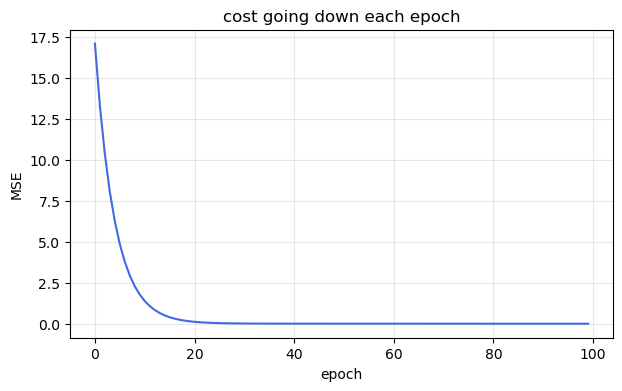

In [8]:
# how the cost dropped over time — should go down and flatten
plt.figure(figsize=(7, 4))
plt.plot(cost_history, color='royalblue')
plt.title('cost going down each epoch')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)
plt.show()

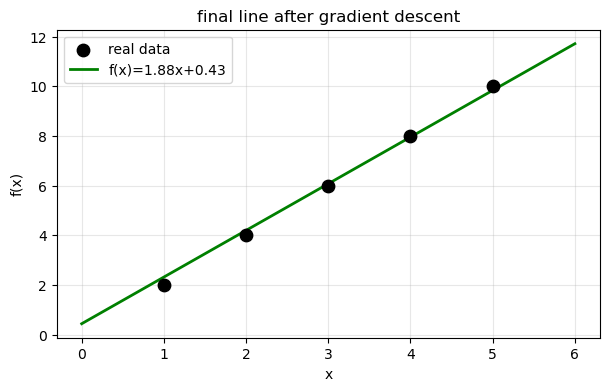

In [9]:
# final line vs real data points
plt.figure(figsize=(7, 4))
plt.scatter(x_train, y_train, color='black', s=80, zorder=5, label='real data')

line_x = [0, 6]
line_y = [w_final * xi + b_final for xi in line_x]
plt.plot(line_x, line_y, color='green', linewidth=2, label=f'f(x)={w_final:.2f}x+{b_final:.2f}')

plt.title('final line after gradient descent')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## what i learned today

- gradient descent finds w and b automatically — no manual testing
- the derivative tells us which direction to move and how steep the slope is
- we subtract because we want to go DOWN the bowl, not up
- alpha (learning rate) controls how big each step is — too big = overshoots, too small = too slow
- epochs = how many times we repeat the update

tomorrow: what happens if alpha is too big or too small — learning rate & convergence